,damage,time,kind,file,record_count
0,CPD,1m,real,R3Hela_1mCPD_GATCAG_S6_hg38_primary_assembly_D...,32539066
1,CPD,15m,real,R3Hela_15mCPD_TAGCTT_S2_hg38_primary_assembly_...,31909633
2,CPD,30m,real,R3Hela_30mCPD_GGCTAC_S8_hg38_primary_assembly_...,33454037
3,CPD,1h,real,R3Hela_1hCPD_CTTGTA_S4_hg38_primary_assembly_D...,34070806
4,CPD,4h,real,R3Hela_4hCPD_AGTCAA_S10_hg38_primary_assembly_...,33084318
5,CPD,8h,real,R3Hela_8hCPD_AGTTCC_S12_hg38_primary_assembly_...,37456000
6,64,1m,real,R3Hela_1m64_CGATGT_S5_hg38_primary_assembly_DS...,24841279
7,64,15m,real,R3Hela_15m64_TTAGGC_S1_hg38_primary_assembly_D...,32381905
8,64,30m,real,R3Hela_30m64_TGACCA_S7_hg38_primary_assembly_D...,48060015
9,64,1h,real,R3Hela_1h64_ACAGTG_S3_hg38_primary_assembly_DS...,24790234


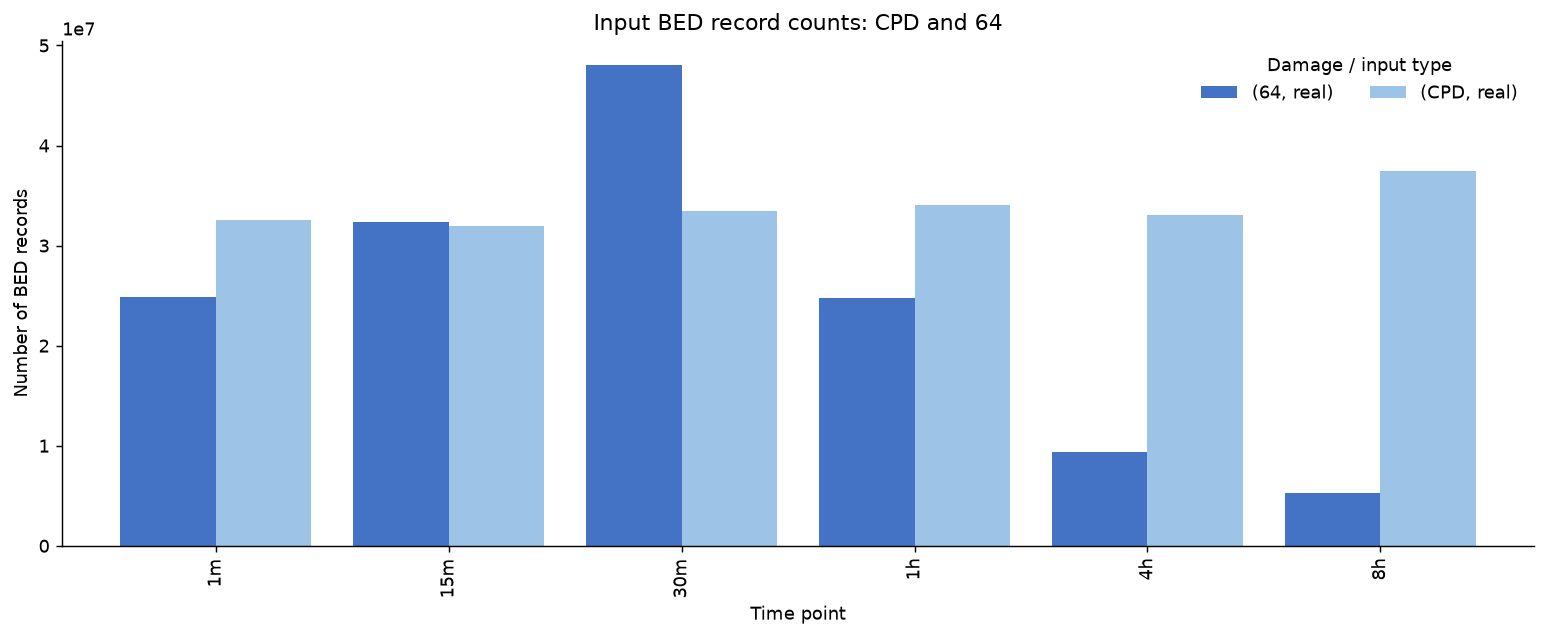

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Count records in the original input Damage-seq BED files.
INPUT_DIR = Path('/cta/users/guneyn23/damageseq_data')
OUTPUT_DIR = Path('/cta/users/guneyn23/damage_profile_trial_20kb_100windows/outputs/input_bed_counts')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TIMES = ['1m', '15m', '30m', '1h', '4h', '8h']
DAMAGES = ['CPD', '64']

rows = []
for damage in DAMAGES:
    for time in TIMES:
        matches = sorted(INPUT_DIR.glob(f'R3Hela_{time}{damage}_*_DS.bed'))
        if not matches:
            raise FileNotFoundError(f'No input BED found for {damage} {time}')
        for path in matches:
            rows.append({
                'damage': damage,
                'time': time,
                'kind': 'sim' if '_sim_' in path.name else 'real',
                'file': path.name,
                'record_count': sum(1 for line in path.open() if line.strip() and not line.startswith('#'))
            })

counts = pd.DataFrame(rows)
counts.to_csv(OUTPUT_DIR / 'input_bed_record_counts.tsv', sep='\t', index=False)
display(counts)

summary = (counts.groupby(['damage', 'time', 'kind'], as_index=False)['record_count']
                 .sum())
summary.to_csv(OUTPUT_DIR / 'input_bed_record_counts_summary.tsv', sep='\t', index=False)

# One combined bar chart for CPD and 64.
plot = summary.pivot_table(index='time', columns=['damage', 'kind'], values='record_count', fill_value=0).reindex(TIMES)
ax = plot.plot(kind='bar', figsize=(12, 5), width=0.82, color=['#4472C4', '#9DC3E6', '#ED7D31', '#F4B183'])
ax.set_title('Input BED record counts: CPD and 64')
ax.set_xlabel('Time point')
ax.set_ylabel('Number of BED records')
ax.legend(title='Damage / input type', frameon=False, ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'input_bed_record_counts.png', dpi=300, bbox_inches='tight')
plt.show()
